# MRI-anchored glioma treatment-scenario framework: main walkthrough

This notebook calls the `glioma_scenarios` package end to end and compares the results:

1. **Anatomy**: patient domain (synthetic phantom, or a real UPENN-GBM case)
2. **Synthetic ground truth**: known parameters, then hidden biology, then MRI-like soft labels
3. **Oracle scenarios**: what each schedule does when the true parameters are known
4. **Inverse fit**: MAP estimate and Laplace uncertainty, compared with the truth
5. **Identifiability**: which parameters and combinations the scan constrains
6. **Laplace vs HMC**: two uncertainty methods compared
7. **Posterior scenarios and treatment-equivalence classes**, compared with the oracle
8. **Effective time since seeding**, as a sensitivity table
9. **Method comparison**: FV solver vs Fisher-KPP discrete-loss vs standard PINN vs renewal-aware PINN
10. **Segmentation robustness**
11. **Real-data anchoring** (UPENN-GBM, only when `USE_REAL_DATA = True`)
12. **Report**

> Research tool: outputs are uncertainty-aware scenarios, **not** individual prescriptions.
> Default parameter values are illustrative priors.

`FAST = True` runs everything in a few minutes on a CPU. Set `FAST = False` for converged
fits, more posterior samples and longer PINN training.

In [1]:
# ---- configuration ---------------------------------------------------------------
FAST = True                    # quick run; set False for thorough results
USE_REAL_DATA = False          # True -> use a UPENN-GBM case (needs the TCIA NIfTI release)
UPENN_ROOT = "/data/UPENN-GBM" # folder containing images_structural/, images_segm/, ...
CASE_ID = "UPENN-GBM-00001_11"
SLICE_AXIS = 2                 # 2-D analysis on the largest-core axial slice (None = full 3-D, slow)
FACTOR = 3                     # down-sampling factor (1 mm -> 3 mm)
SEED = 0
RESULTS = "results/notebook"

S = dict(
    grid=48 if FAST else 64,
    dt=0.5 if FAST else 0.25,
    n_adam=60 if FAST else 200,
    n_lbfgs=10 if FAST else 30,
    n_samples=16 if FAST else 64,
    horizon=42.0 if FAST else 84.0,
    hmc_samples=60 if FAST else 300,
    hmc_warmup=20 if FAST else 100,
    pinn_iters=1500 if FAST else 5000,
    pinn_grid=32 if FAST else 48,
    profile_points=5 if FAST else 9,
    robustness_levels=(0.0, 0.7, 1.4) if FAST else (0.0, 0.5, 1.0, 1.5, 2.0),
)
S

{'grid': 48,
 'dt': 0.5,
 'n_adam': 60,
 'n_lbfgs': 10,
 'n_samples': 16,
 'horizon': 42.0,
 'hmc_samples': 60,
 'hmc_warmup': 20,
 'pinn_iters': 1500,
 'pinn_grid': 32,
 'profile_points': 5,
 'robustness_levels': (0.0, 0.7, 1.4)}

In [2]:
import sys, time, json
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

ROOT = Path.cwd()
if not (ROOT / "glioma_scenarios").exists():   # allow running from notebooks/ subfolder
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
OUT = ROOT / RESULTS
OUT.mkdir(parents=True, exist_ok=True)

from glioma_scenarios.domain import phantom_domain, LABEL_CLASSES
from glioma_scenarios.forward import GliomaModel, param_tensors, summarize_state
from glioma_scenarios.observation import ObservationModel, synthesize_observation
from glioma_scenarios.params import ModelParams, PARAM_SPECS, provenance_table
from glioma_scenarios.pk import standard_scenarios, daily, plasma_concentration
from glioma_scenarios.synthetic import make_synthetic_case, recovery_experiment, segmentation_robustness
from glioma_scenarios.inference import SeedingInverseProblem
from glioma_scenarios.identifiability import (information_directions, classify_parameters,
                                              profile_likelihood)
from glioma_scenarios.scenarios import (ScenarioConfig, run_scenarios, equivalence_classes,
                                        outcome_summary, compare)
from glioma_scenarios.seeding import seeding_time_sensitivity, seeding_statement
from glioma_scenarios.baselines import FisherKPPInversion
from glioma_scenarios.pinn import GliomaPINN, PINNConfig
from glioma_scenarios.report import markdown_report, save_json

rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)
pd.set_option("display.precision", 3)
pd.set_option("display.max_colwidth", 120)

In [3]:
# ---- plotting style ----------------------------------------------------------------
# Categorical slots in fixed order (validated for CVD separation). Three slots are below
# 3:1 contrast on white, so every chart has a legend, and tables print the same numbers.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
DASHES = ["-", "--", "-.", ":", (0, (5, 1)), (0, (3, 1, 1, 1))]  # secondary encoding
TEXT, TEXT2, GRID = "#0b0b0b", "#52514e", "#e4e3df"
SEQ = LinearSegmentedColormap.from_list("seq_blue", ["#f4f8fd", "#86b6ef", "#2a78d6", "#0d366b"])
DIV = LinearSegmentedColormap.from_list("div", ["#eb6834", "#e9e8e4", "#2a78d6"])  # neutral gray midpoint
LABEL_CMAP = ListedColormap(["#f2f1ed", SERIES[1], SERIES[3], SERIES[0]])  # bg, necrotic, edema, enhancing

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor": GRID, "axes.labelcolor": TEXT2, "xtick.color": TEXT2, "ytick.color": TEXT2,
    "text.color": TEXT, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "lines.linewidth": 2,
    "legend.frameon": False, "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
})

def show_map(ax, arr, title, mask=None, cmap=SEQ, vmin=None, vmax=None, cbar=True):
    a = np.array(arr, float)
    if mask is not None:
        a = np.where(mask, a, np.nan)
    im = ax.imshow(a.T, origin="lower", cmap=cmap, vmin=vmin, vmax=vmax, interpolation="nearest")
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    if cbar:
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    return im

def savefig(fig, name):
    fig.savefig(OUT / f"{name}.png", dpi=130, bbox_inches="tight")

## 1. Anatomy: the patient-specific computational domain

`BrainDomain` holds the brain mask, the tumour-cell motility map `m(x)` (white matter 1,
gray matter ≈ 0.2, CSF excluded), and the permeability proxy `V(x)`. For a real case these come
from the preprocessing pipeline:

* motility: GMM tissue maps plus DTI FA;
* permeability: T1-Gd enhancement plus rCBV;
* observations: down-sampling the expert labels gives partial-volume soft labels.

grid (48, 48), spacing (3.3333333333333335, 3.3333333333333335) mm, brain voxels 1108, source: phantom


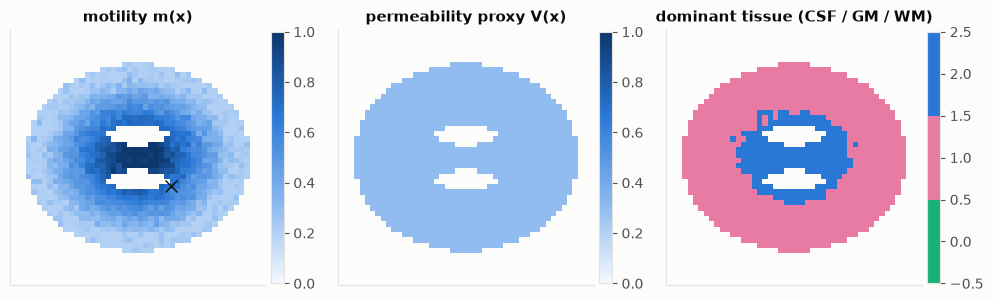

In [4]:
if USE_REAL_DATA:
    from glioma_scenarios.data.upenn import index_dataset, load_case
    from glioma_scenarios.preprocess import build_domain
    cases = index_dataset(UPENN_ROOT)
    case = cases[CASE_ID]
    real_domain = build_domain(load_case(case), factor=FACTOR, slice_axis=SLICE_AXIS, case_id=case.case_id)
    domain = real_domain
    center = domain.tumour_core_centroid()
else:
    real_domain = None
    g = S["grid"]
    domain = phantom_domain((g, g), spacing=160.0 / g)
    center = (0.62 * g, 0.38 * g)

print(f"grid {domain.shape}, spacing {domain.spacing} mm, brain voxels {int(domain.mask.sum())}, "
      f"source: {domain.meta.get('source')}")
fig, axs = plt.subplots(1, 3, figsize=(12, 3.6))
show_map(axs[0], domain.mobility, "motility m(x)", domain.mask, vmin=0, vmax=1)
show_map(axs[1], domain.permeability, "permeability proxy V(x)", domain.mask, vmin=0, vmax=1)
tissue_idx = domain.tissue.argmax(0) if domain.tissue is not None else domain.mask.astype(int)
show_map(axs[2], np.where(domain.mask, tissue_idx, np.nan), "dominant tissue (CSF / GM / WM)",
         cmap=ListedColormap([SERIES[2], SERIES[4], SERIES[0]]), vmin=-0.5, vmax=2.5)
axs[0].plot(center[0], center[1], "x", color=TEXT, ms=8)
savefig(fig, "01_anatomy"); plt.show()

## 2. Synthetic ground truth

Known parameters are pushed through the finite-volume solver, which gives the hidden cycling,
quiescent and necrotic populations plus the immune field. The observation model then turns them
into MRI-like soft labels. Correlated boundary noise emulates segmentation error. **Only the
observations are given to the inverse methods.**

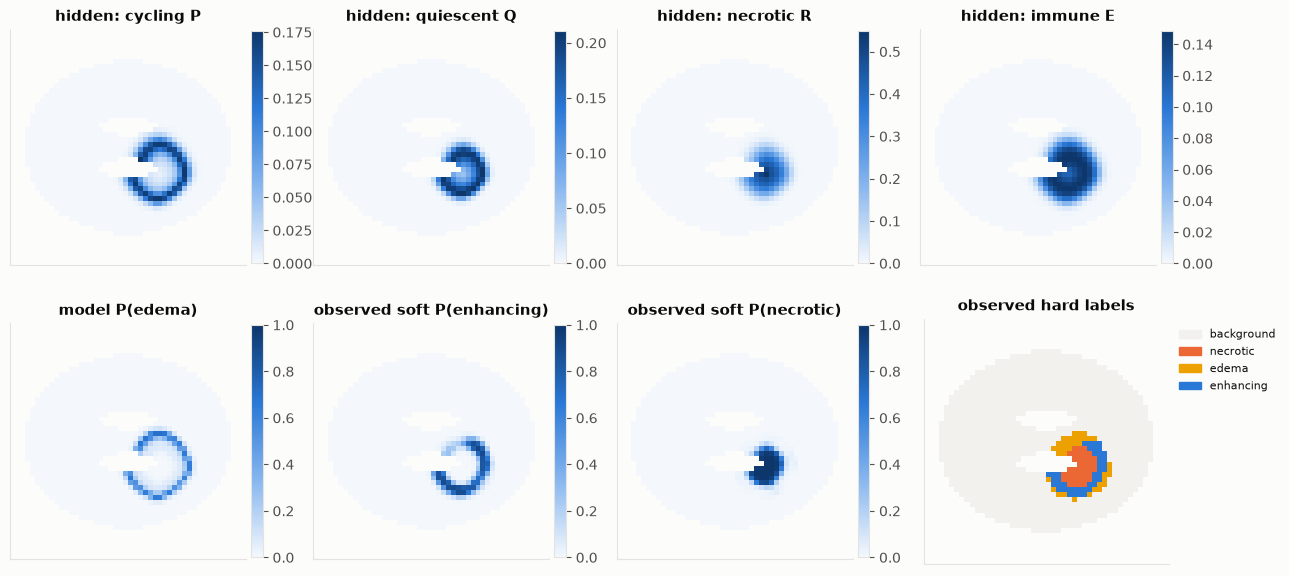

true burdens (carrying-capacity x mL): {'P': 0.137, 'q': 0.144, 'r': 0.254}


In [5]:
TRUTH = ModelParams({"D_white": 0.35, "beta_max": 0.9, "mu_p": 0.06, "T_seed": 50.0})
FIT_NAMES = ["D_white", "beta_max", "mu_p", "T_seed"]
syn = make_synthetic_case(domain, TRUTH, center, rng, dt=S["dt"], boundary_noise=0.7)
sdom, truth_state, obs = syn["domain"], syn["state"], syn["obs"]

fig, axs = plt.subplots(2, 4, figsize=(15, 7))
m = domain.mask
show_map(axs[0, 0], truth_state["P"], "hidden: cycling P", m)
show_map(axs[0, 1], truth_state["q"], "hidden: quiescent Q", m)
show_map(axs[0, 2], truth_state["r"], "hidden: necrotic R", m)
show_map(axs[0, 3], truth_state["E"], "hidden: immune E", m)
show_map(axs[1, 0], syn["pi"][2], "model P(edema)", m, vmin=0, vmax=1)
show_map(axs[1, 1], obs["soft"][3], "observed soft P(enhancing)", m, vmin=0, vmax=1)
show_map(axs[1, 2], obs["soft"][1], "observed soft P(necrotic)", m, vmin=0, vmax=1)
show_map(axs[1, 3], np.where(m, obs["hard"], np.nan), "observed hard labels", cmap=LABEL_CMAP,
         vmin=-0.5, vmax=3.5, cbar=False)
from matplotlib.patches import Patch
axs[1, 3].legend(handles=[Patch(color=LABEL_CMAP(i), label=c) for i, c in enumerate(LABEL_CLASSES)],
                 loc="upper left", bbox_to_anchor=(1.0, 1.0), fontsize=8)
savefig(fig, "02_truth_and_observation"); plt.show()

vv = domain.voxel_volume_ml
print("true burdens (carrying-capacity x mL):",
      {k: round(float(truth_state[k].sum()) * vv, 3) for k in ("P", "q", "r")})

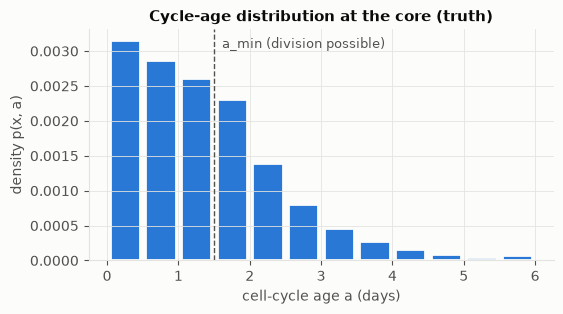

In [6]:
# cell-cycle age distribution of cycling cells at the tumour core (hidden, not visible on MRI)
model_true = GliomaModel(domain, dt=S["dt"])
ci = tuple(int(round(c)) for c in center)
p_age = truth_state["p"][(slice(None),) + ci] / model_true.da
ages = (np.arange(model_true.n_age) + 0.5) * model_true.da
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(ages, p_age, width=model_true.da * 0.85, color=SERIES[0], edgecolor="#fcfcfb", linewidth=2)
ax.axvline(TRUTH["a_min"], color=TEXT2, lw=1, ls="--")
ax.text(TRUTH["a_min"], ax.get_ylim()[1] * 0.92, "  a_min (division possible)", color=TEXT2, fontsize=9)
ax.set_xlabel("cell-cycle age a (days)"); ax.set_ylabel("density p(x, a)")
ax.set_title("Cycle-age distribution at the core (truth)")
savefig(fig, "02b_age_distribution"); plt.show()

## 3. Oracle scenarios: true parameters known

Each schedule is simulated from the **true** scan-time state with the true kinetics, and the
drug and immune parameters at their prior medians. No real analysis has this; it is the
reference that the posterior scenarios in section 7 are compared against.

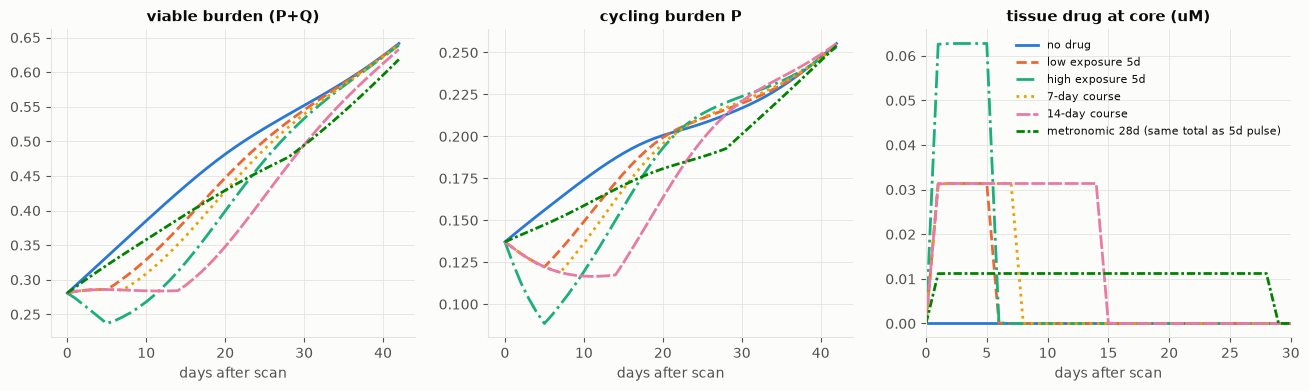

,total dose (mg),mean viable,viable at horizon,core mL at horizon
no drug,0.0,0.476,0.641,3.305
low exposure 5d,675.0,0.451,0.641,3.230
high exposure 5d,1350.0,0.420,0.639,3.133
7-day course,945.0,0.440,0.640,3.200
14-day course,1890.0,0.403,0.633,3.087
metronomic 28d (same total as 5d pulse),1350.0,0.438,0.618,3.184


In [7]:
schedules = standard_scenarios()
P_true = param_tensors(TRUTH)
obs_model = ObservationModel(domain)
oracle = {}
with torch.no_grad():
    s0 = model_true.grow_from_seed(P_true, center)
    for sch in schedules:
        rec = {"t": [], "viable": [], "cycling": [], "core_ml": [], "drug_core": []}
        def cb(st, rec=rec):
            rec["t"].append(st.t); rec["viable"].append(float((st.P + st.q).sum()) * vv)
            rec["cycling"].append(float(st.P.sum()) * vv)
            rec["core_ml"].append(obs_model.visible_volume_ml(obs_model.probabilities_from_state(st, P_true))["core"])
            rec["drug_core"].append(float(st.C[ci]))
        model_true.run(s0, P_true, S["horizon"], sch, callback=cb, record_every=1.0)
        oracle[sch.name] = {k: np.array(v) for k, v in rec.items()}

fig, axs = plt.subplots(1, 3, figsize=(16, 4))
for i, sch in enumerate(schedules):
    o = oracle[sch.name]
    kw = dict(color=SERIES[i], ls=DASHES[i], label=sch.name)
    axs[0].plot(o["t"], o["viable"], **kw)
    axs[1].plot(o["t"], o["cycling"], **kw)
    axs[2].plot(o["t"], o["drug_core"], **kw)
axs[0].set_title("viable burden (P+Q)"); axs[1].set_title("cycling burden P")
axs[2].set_title("tissue drug at core (uM)"); axs[2].set_xlim(0, 30)
for a in axs: a.set_xlabel("days after scan")
axs[2].legend(loc="upper right", fontsize=8)
savefig(fig, "03_oracle_scenarios"); plt.show()

pd.DataFrame({s.name: {"total dose (mg)": s.total_dose,
                       "mean viable": oracle[s.name]["viable"].mean(),
                       "viable at horizon": oracle[s.name]["viable"][-1],
                       "core mL at horizon": oracle[s.name]["core_ml"][-1]} for s in schedules}).T

## 4. Inverse fit from the synthetic scan: MAP and Laplace

The inverse problem fits `D_white`, `beta_max`, `mu_p` and `T_seed` (in log space, with
log-normal priors) by differentiating through the finite-volume solver. Uncertainty comes from a
Laplace approximation with expected-Fisher curvature.

MAP fit: 38.5s, obs weight 0.694


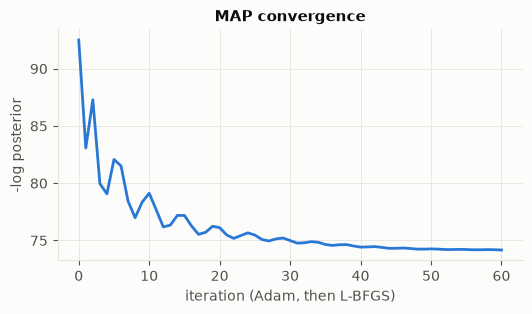

,truth,MAP,ci90_low,ci90_high,truth_in_ci90,variance_reduction
parameter,,,,,,
D_white,0.35,0.369,0.259,0.525,True,0.928
beta_max,0.90,0.673,0.341,1.328,True,0.317
mu_p,0.06,0.062,0.039,0.097,True,0.793
T_seed,50.00,54.455,43.138,68.741,True,0.920


In [8]:
ip = SeedingInverseProblem(sdom, obs["soft"], FIT_NAMES, center_vox=center, dt=S["dt"])
fit = ip.fit_map(n_adam=S["n_adam"], lr=0.05, n_lbfgs=S["n_lbfgs"])
post = ip.laplace(fit.theta)
F = ip.fisher_information(fit.theta)
print(f"MAP fit: {fit.seconds:.1f}s, obs weight {ip.obs.obs_weight:.3f}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(fit.history, color=SERIES[0])
ax.set_xlabel("iteration (Adam, then L-BFGS)"); ax.set_ylabel("-log posterior")
ax.set_title("MAP convergence")
savefig(fig, "04_map_convergence"); plt.show()

rows = []
for r in post.summary():
    t = TRUTH[r["name"]]
    rows.append(dict(parameter=r["name"], truth=t, MAP=r["map"], ci90_low=r["ci90"][0], ci90_high=r["ci90"][1],
                     truth_in_ci90=r["ci90"][0] <= t <= r["ci90"][1], variance_reduction=r["contraction"]))
fit_table = pd.DataFrame(rows).set_index("parameter")
fit_table

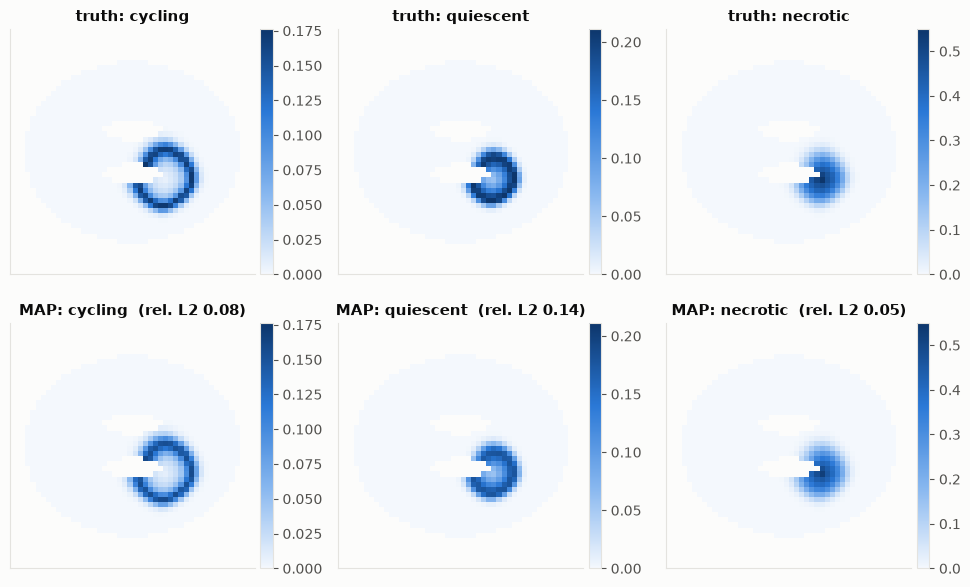

In [9]:
# hidden-state recovery at the scan: fitted vs true fields
with torch.no_grad():
    fit_state = ip.state(fit.theta).to_numpy()
def rel_l2(a, b, m=domain.mask):
    return float(np.linalg.norm(a[m] - b[m]) / max(np.linalg.norm(b[m]), 1e-12))

fig, axs = plt.subplots(2, 3, figsize=(12, 7))
for j, (k, name) in enumerate((("P", "cycling"), ("q", "quiescent"), ("r", "necrotic"))):
    vmax = max(truth_state[k].max(), fit_state[k].max())
    show_map(axs[0, j], truth_state[k], f"truth: {name}", m, vmin=0, vmax=vmax)
    show_map(axs[1, j], fit_state[k], f"MAP: {name}  (rel. L2 {rel_l2(fit_state[k], truth_state[k]):.2f})",
             m, vmin=0, vmax=vmax)
savefig(fig, "04b_state_recovery"); plt.show()

## 5. Identifiability

The Fisher information is whitened by the prior widths. Each eigenvector is a power-law
combination of parameters, and its eigenvalue is the data-to-prior information ratio. A
parameter is *identifiable* when its own posterior variance shrinks by at least 75%.
Otherwise it may still be *identifiable in combination*, or *not identifiable*. Drug and immune
parameters are never informed by a pre-treatment scan.

,combination,info/prior ratio,posterior/prior variance,informative
0,D_white^+0.46 * beta_max^+0.38 * mu_p^-0.27 * T_seed^+1.00,2515.495,3.974e-04,True
1,beta_max^-0.36 * mu_p^+1.00 * T_seed^+0.44,36.023,2.701e-02,True
2,D_white^+1.00 * beta_max^-0.35 * T_seed^-0.31,17.275,5.472e-02,True
3,D_white^+0.20 * beta_max^+1.00 * mu_p^+0.53 * T_seed^-0.33,0.042,9.599e-01,False


,verdict,contraction
name,,
D_white,identifiable,0.928
beta_max,identifiable only in combination,0.317
mu_p,identifiable,0.793
T_seed,identifiable,0.920


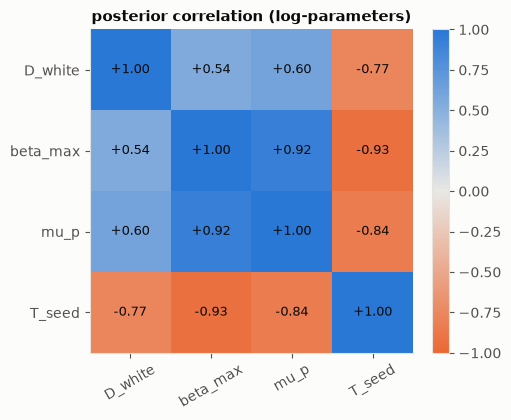

In [10]:
dirs = information_directions(F, FIT_NAMES)
display(pd.DataFrame([{"combination": d["combination"], "info/prior ratio": d["info_ratio"],
                       "posterior/prior variance": d["posterior_to_prior_var"],
                       "informative": d["informative"]} for d in dirs]))
ident = classify_parameters(F, FIT_NAMES, include_unfitted=False)
display(pd.DataFrame(ident).set_index("name")[["verdict", "contraction"]])

corr = post.correlation()
fig, ax = plt.subplots(figsize=(5, 4.2))
im = ax.imshow(corr, cmap=DIV, vmin=-1, vmax=1)
ax.set_xticks(range(len(FIT_NAMES)), FIT_NAMES, rotation=30); ax.set_yticks(range(len(FIT_NAMES)), FIT_NAMES)
ax.grid(False)
for i in range(len(FIT_NAMES)):
    for j in range(len(FIT_NAMES)):
        ax.text(j, i, f"{corr[i, j]:+.2f}", ha="center", va="center", fontsize=9, color=TEXT)
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title("posterior correlation (log-parameters)")
savefig(fig, "05_posterior_correlation"); plt.show()

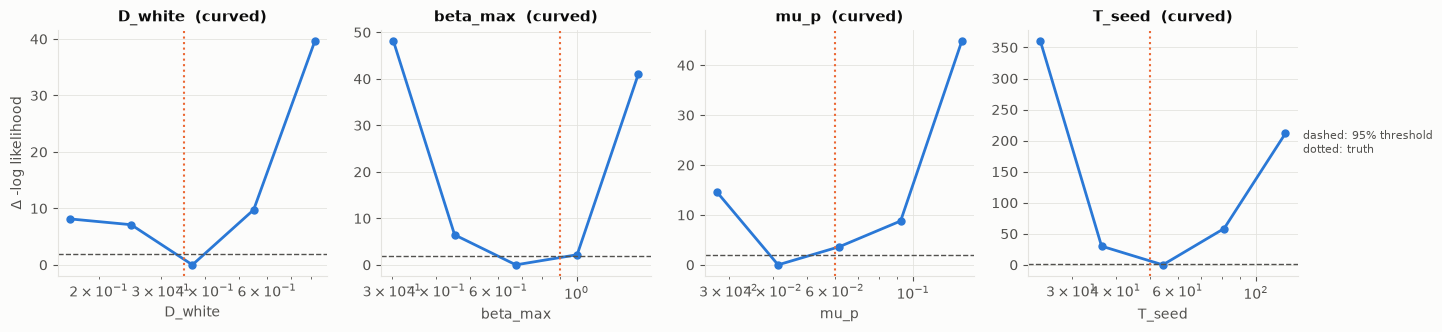

In [11]:
# profile likelihood: a flat profile (rise < 1.92) means practically non-identifiable
fig, axs = plt.subplots(1, len(FIT_NAMES), figsize=(4 * len(FIT_NAMES), 3.2))
profiles = {}
for ax, name in zip(axs, FIT_NAMES):
    i = FIT_NAMES.index(name)
    grid = np.exp(fit.theta[i] + np.linspace(-0.8, 0.8, S["profile_points"]))
    pr = profile_likelihood(ip, name, grid, fit.theta, n_adam=10 if FAST else 40)
    profiles[name] = pr
    ax.plot(pr["grid"], pr["rise"], "o-", color=SERIES[0], ms=5)
    ax.axhline(1.92, color=TEXT2, lw=1, ls="--")
    ax.axvline(TRUTH[name], color=SERIES[1], lw=1.5, ls=":")
    ax.set_xscale("log"); ax.set_title(f"{name}  ({'flat' if pr['flat'] else 'curved'})")
    ax.set_xlabel(name)
axs[0].set_ylabel("Δ -log likelihood")
axs[-1].text(1.02, 0.5, "dashed: 95% threshold\ndotted: truth", transform=axs[-1].transAxes, fontsize=8, color=TEXT2)
savefig(fig, "05b_profile_likelihood"); plt.show()

## 6. Uncertainty: Laplace vs HMC

HMC samples the same log-parameter posterior without the Gaussian assumption. Its mass matrix
comes from the Laplace variances. In `FAST` mode the chain is short (60 draws), so a much
narrower HMC spread than Laplace means the chain has not mixed; it is not evidence of a tighter
posterior. Use `FAST = False` for a real comparison.

HMC: 154.6s, acceptance 0.63


,truth,laplace_median,laplace_q05,laplace_q95,hmc_median,hmc_q05,hmc_q95
parameter,,,,,,,
D_white,0.35,0.368,0.260,0.520,0.374,0.316,0.417
beta_max,0.90,0.684,0.337,1.316,0.506,0.429,0.654
mu_p,0.06,0.062,0.039,0.096,0.051,0.043,0.063
T_seed,50.00,54.212,43.069,68.148,58.637,54.123,61.437


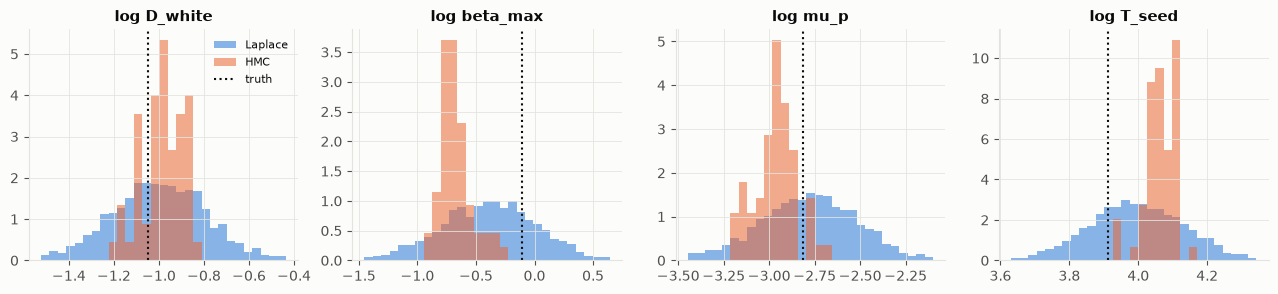

In [12]:
t0 = time.time()
hmc = ip.hmc(fit.theta, n_samples=S["hmc_samples"], n_warmup=S["hmc_warmup"], step_size=0.2, n_leapfrog=5,
             mass_diag=1.0 / np.diag(post.cov), rng=rng)
print(f"HMC: {time.time() - t0:.1f}s, acceptance {float(hmc['_acceptance']):.2f}")
lap = post.sample(2000, rng)
rows = []
for k in FIT_NAMES:
    rows.append(dict(parameter=k, truth=TRUTH[k],
                     laplace_median=np.median(lap[k]), laplace_q05=np.quantile(lap[k], .05), laplace_q95=np.quantile(lap[k], .95),
                     hmc_median=np.median(hmc[k]), hmc_q05=np.quantile(hmc[k], .05), hmc_q95=np.quantile(hmc[k], .95)))
display(pd.DataFrame(rows).set_index("parameter"))

fig, axs = plt.subplots(1, len(FIT_NAMES), figsize=(4 * len(FIT_NAMES), 3))
for ax, k in zip(axs, FIT_NAMES):
    bins = np.linspace(*np.log(np.quantile(np.r_[lap[k], hmc[k]], [0.005, 0.995])), 30)
    ax.hist(np.log(lap[k]), bins=bins, density=True, color=SERIES[0], alpha=0.55, label="Laplace")
    ax.hist(np.log(hmc[k]), bins=bins, density=True, color=SERIES[1], alpha=0.55, label="HMC")
    ax.axvline(np.log(TRUTH[k]), color=TEXT, lw=1.5, ls=":", label="truth")
    ax.set_title(f"log {k}")
axs[0].legend(fontsize=8)
savefig(fig, "06_laplace_vs_hmc"); plt.show()

## 7. Posterior treatment scenarios and treatment-equivalence classes

For each posterior draw of the fitted kinetics, combined with a prior draw of the drug and
immune parameters, every schedule is simulated from the same reconstructed scan state (common
random numbers). Each pair of schedules is then classified as *distinguishable*, *equivalent at
available resolution* or *not supported*. The classification also records how much of the
comparison depends on prior-only parameters.

In [13]:
draws = post.sample(S["n_samples"], rng)
scfg = ScenarioConfig(horizon_days=S["horizon"], dt=S["dt"])
res = run_scenarios(sdom, schedules, draws, S["n_samples"], center_vox=center, config=scfg, rng=rng)
print(f"{S['n_samples']} draws x {len(schedules)} schedules in {res.seconds:.1f}s")
summ = outcome_summary(res)
pd.DataFrame([{"schedule": r["schedule"], "dose mg": r["total_dose_mg"],
               "mean viable (median)": r["auc_viable"]["median"],
               "mean viable 90%": f"[{r['auc_viable']['q05']:.3g}, {r['auc_viable']['q95']:.3g}]",
               "TTP days (median)": r["ttp_days"]["median"],
               "fraction progressed": r["fraction_progressed"]} for r in summ]).set_index("schedule")

16 draws x 6 schedules in 12.0s


,dose mg,mean viable (median),mean viable 90%,TTP days (median),fraction progressed
schedule,,,,,
no drug,0.0,0.450,"[0.287, 0.534]",9.0,1.000
low exposure 5d,675.0,0.354,"[0.202, 0.477]",14.5,1.000
high exposure 5d,1350.0,0.295,"[0.136, 0.468]",20.0,0.938
7-day course,945.0,0.324,"[0.168, 0.472]",16.0,0.938
14-day course,1890.0,0.251,"[0.0738, 0.468]",19.5,0.875
metronomic 28d (same total as 5d pulse),1350.0,0.283,"[0.0897, 0.477]",11.5,0.875


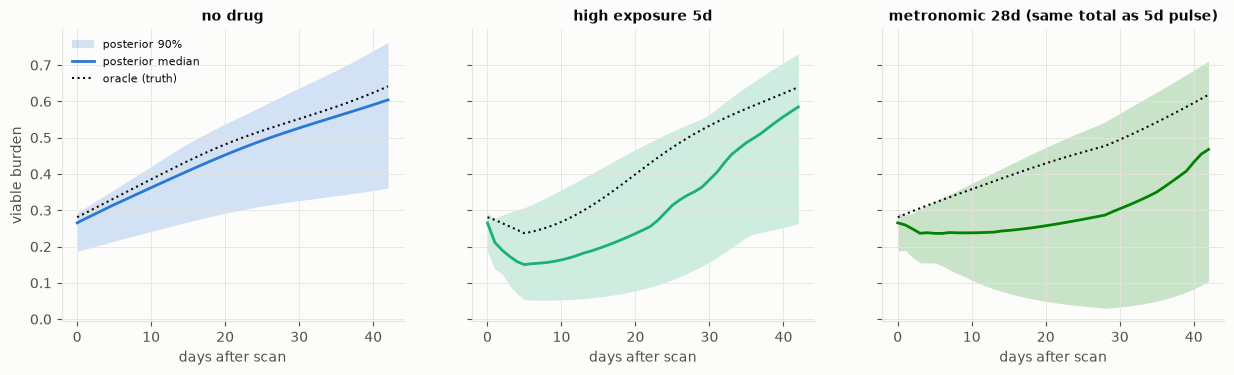

,fraction of days oracle inside posterior 90% band
no drug,1.000
low exposure 5d,0.977
high exposure 5d,1.000
7-day course,0.977
14-day course,0.977
metronomic 28d (same total as 5d pulse),0.930


In [14]:
# posterior bands vs oracle for three contrasting schedules
show = ["no drug", "high exposure 5d", "metronomic 28d (same total as 5d pulse)"]
fig, axs = plt.subplots(1, len(show), figsize=(15, 3.8), sharey=True)
for ax, name in zip(axs, show):
    i = [s.name for s in schedules].index(name)
    tr = res.trajectories[name]
    t = tr["times"]
    lo, med, hi = np.quantile(tr["viable"], [0.05, 0.5, 0.95], axis=0)
    ax.fill_between(t, lo, hi, color=SERIES[i], alpha=0.2, lw=0, label="posterior 90%")
    ax.plot(t, med, color=SERIES[i], label="posterior median")
    ax.plot(oracle[name]["t"], oracle[name]["viable"], color=TEXT, ls=":", lw=1.5, label="oracle (truth)")
    ax.set_title(name, fontsize=10); ax.set_xlabel("days after scan")
axs[0].set_ylabel("viable burden"); axs[0].legend(fontsize=8)
savefig(fig, "07_posterior_vs_oracle"); plt.show()

cover = {}
for s in schedules:
    lo, hi = np.quantile(res.trajectories[s.name]["viable"], [0.05, 0.95], axis=0)
    o = oracle[s.name]["viable"][: len(lo)]
    cover[s.name] = float(np.mean((o >= lo) & (o <= hi)))
pd.Series(cover, name="fraction of days oracle inside posterior 90% band").to_frame()

Treatment-equivalence classes (mean viable burden):
  1. no drug
  2. low exposure 5d
  3. high exposure 5d
  4. 7-day course
  5. 14-day course
  6. metronomic 28d (same total as 5d pulse)


,a,b,verdict,better,direction,p_a_better,p_b_better,p_equivalent,prior_driven_share
0,no drug,low exposure 5d,not supported,None,low exposure 5d,0.000,0.625,0.375,0.618
1,no drug,high exposure 5d,not supported,None,high exposure 5d,0.000,0.750,0.250,0.610
2,no drug,7-day course,not supported,None,7-day course,0.000,0.625,0.375,0.619
3,no drug,14-day course,not supported,None,14-day course,0.000,0.812,0.188,0.552
4,no drug,metronomic 28d (same total as 5d pulse),not supported,None,metronomic 28d (same total as 5d pulse),0.000,0.625,0.375,0.505
5,low exposure 5d,high exposure 5d,not supported,None,high exposure 5d,0.000,0.625,0.375,0.600
6,low exposure 5d,7-day course,not supported,None,7-day course,0.000,0.375,0.625,0.620
7,low exposure 5d,14-day course,not supported,None,14-day course,0.000,0.750,0.250,0.498
8,low exposure 5d,metronomic 28d (same total as 5d pulse),not supported,None,NaN,0.000,0.438,0.562,0.387
9,high exposure 5d,7-day course,not supported,None,NaN,0.438,0.000,0.562,0.581


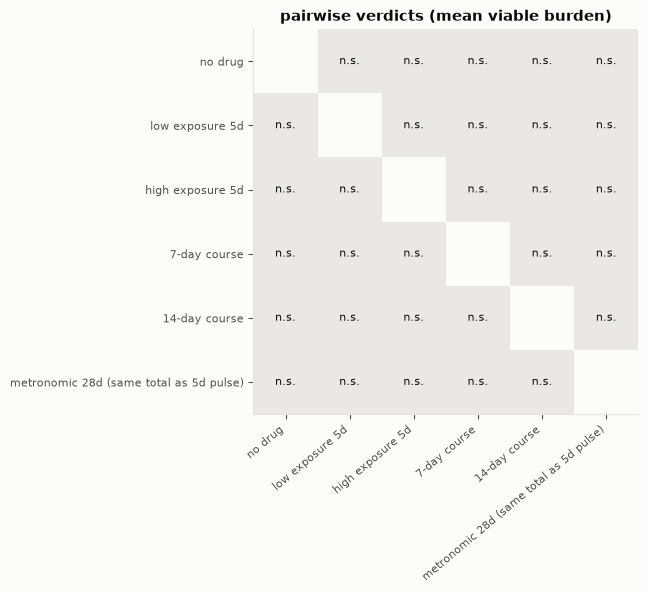

- No reliable comparison of 'no drug' vs 'low exposure 5d' on auc_viable: the relevant parameters are not constrained enough (driven mainly by population drug/immune priors). The direction favours 'low exposure 5d' in >= 90% of draws, but the size of the difference is not resolved relative to the 10% margin.
- No reliable comparison of 'no drug' vs 'high exposure 5d' on auc_viable: the relevant parameters are not constrained enough (driven mainly by population drug/immune priors). The direction favours 'high exposure 5d' in >= 90% of draws, but the size of the difference is not resolved relative to the 10% margin.
- No reliable comparison of 'no drug' vs '7-day course' on auc_viable: the relevant parameters are not constrained enough (driven mainly by population drug/immune priors). The direction favours '7-day course' in >= 90% of draws, but the size of the difference is not resolved relative to the 10% margin.
- No reliable comparison of 'no drug' vs '14-day course' on auc_viable: th

In [15]:
eq = equivalence_classes(res, "auc_viable")
print("Treatment-equivalence classes (mean viable burden):")
for i, c in enumerate(eq["classes"], 1):
    print(f"  {i}. " + ", ".join(c))
pairs = pd.DataFrame([{k: p[k] for k in ("a", "b", "verdict", "better", "direction", "p_a_better", "p_b_better",
                                         "p_equivalent", "prior_driven_share")} for p in eq["pairs"]])
display(pairs)

names = [s.name for s in schedules]
code_of = {"distinguishable": 2, "equivalent": 1, "not supported": 0}
Mv = np.full((len(names), len(names)), np.nan)
for p in eq["pairs"]:
    i, j = names.index(p["a"]), names.index(p["b"])
    Mv[i, j] = Mv[j, i] = code_of[p["verdict"]]
fig, ax = plt.subplots(figsize=(6.5, 5))
cm = ListedColormap(["#e9e8e4", SERIES[2], SERIES[0]])
ax.imshow(Mv, cmap=cm, vmin=-0.5, vmax=2.5)
ax.set_xticks(range(len(names)), names, rotation=40, ha="right", fontsize=8)
ax.set_yticks(range(len(names)), names, fontsize=8); ax.grid(False)
for i in range(len(names)):
    for j in range(len(names)):
        if i != j:
            ax.text(j, i, ["n.s.", "equiv", "dist"][int(Mv[i, j])], ha="center", va="center", fontsize=8,
                    color="#ffffff" if Mv[i, j] == 2 else TEXT)
ax.set_title("pairwise verdicts (mean viable burden)")
savefig(fig, "07b_verdicts"); plt.show()
for p in eq["pairs"]:
    print("-", p["statement"])

In [16]:
# the same comparisons evaluated on the oracle (what the truth would say, without uncertainty)
oracle_rows = []
for p in eq["pairs"]:
    a, b = oracle[p["a"]]["viable"].mean(), oracle[p["b"]]["viable"].mean()
    oracle_rows.append(dict(a=p["a"], b=p["b"], oracle_log_ratio=np.log(a / b),
                            posterior_median_log_ratio=p["median_log_ratio"],
                            posterior_ci90=p["ci90_log_ratio"], verdict=p["verdict"]))
pd.DataFrame(oracle_rows)

,a,b,oracle_log_ratio,posterior_median_log_ratio,posterior_ci90,verdict
0,no drug,low exposure 5d,0.054,0.149,"[0.0024583259375468595, 0.7041071251770208]",not supported
1,no drug,high exposure 5d,0.125,0.310,"[0.008569589850808346, 1.2563908560199915]",not supported
2,no drug,7-day course,0.077,0.209,"[0.0034488313877246526, 1.01573350532998]",not supported
3,no drug,14-day course,0.165,0.430,"[0.006872006474598449, 1.9225526958081818]",not supported
4,no drug,metronomic 28d (same total as 5d pulse),0.082,0.165,"[0.002175371083009694, 1.7050864270816002]",not supported
5,low exposure 5d,high exposure 5d,0.071,0.151,"[0.006246187510014951, 0.5522837308429709]",not supported
6,low exposure 5d,7-day course,0.023,0.059,"[0.000990505450177987, 0.3138197693587852]",not supported
7,low exposure 5d,14-day course,0.111,0.280,"[0.004413680537051677, 1.2325363095907587]",not supported
8,low exposure 5d,metronomic 28d (same total as 5d pulse),0.028,0.051,"[-0.02157549929340536, 0.9629832799556306]",not supported
9,high exposure 5d,7-day course,-0.048,-0.072,"[-0.24065735069001154, 0.03253708293352844]",not supported


## 8. Effective time since seeding

`T_seed` is a **model-dependent** quantity, not an observed tumour age. Refitting under
alternative assumptions (seed size, detection threshold) shows how far it moves.

,median,q05,q95
assumption,,,
baseline,55.622,45.736,69.904
small seed (x0.3),59.586,46.818,73.601
large seed (x3),53.771,42.913,67.708
sensitive detection,56.481,46.017,70.357
insensitive detection,56.482,44.810,71.386


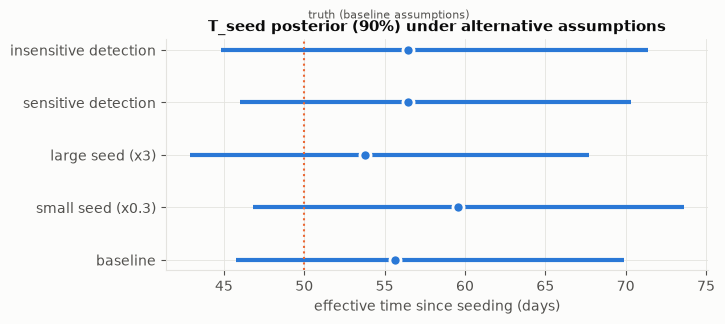

Effective time since seeding (model-dependent, not an observed tumour age): 90% intervals across the tested assumptions span 43-74 days.


In [17]:
assump = {"baseline": {}, "small seed (x0.3)": {"seed_amp": 0.09}, "large seed (x3)": {"seed_amp": 0.9},
          "sensitive detection": {"obs_th_edema": 0.04}, "insensitive detection": {"obs_th_edema": 0.16}}
seed_rows = seeding_time_sensitivity(sdom, obs["soft"], assumptions=assump, fit_names=FIT_NAMES, rng=rng,
                                     fit_kwargs=dict(n_adam=S["n_adam"] // 2, lr=0.05, n_lbfgs=0),
                                     center_vox=center, dt=S["dt"])
seed_df = pd.DataFrame([{"assumption": r["assumption"], **r["T_seed_days"]} for r in seed_rows]).set_index("assumption")
display(seed_df)
fig, ax = plt.subplots(figsize=(7, 3))
y = np.arange(len(seed_df))
ax.hlines(y, seed_df["q05"], seed_df["q95"], color=SERIES[0], lw=3)
ax.plot(seed_df["median"], y, "o", color=SERIES[0], ms=8, mec="#fcfcfb", mew=2)
ax.axvline(TRUTH["T_seed"], color=SERIES[1], ls=":", lw=1.5)
ax.text(TRUTH["T_seed"], len(seed_df) - 0.4, " truth (baseline assumptions)", color=TEXT2, fontsize=8)
ax.set_yticks(y, seed_df.index); ax.set_xlabel("effective time since seeding (days)")
ax.set_title("T_seed posterior (90%) under alternative assumptions")
savefig(fig, "08_seeding"); plt.show()
print(seeding_statement(seed_rows))

## 9. Method comparison: FV vs Fisher-KPP vs standard PINN vs renewal-aware PINN

A synthetic tumour is treated with a 5-day course. The PINNs see the scan (t = 0) and a
synthetic follow-up. The one-density Fisher-KPP baseline sees the scan only, and it cannot
separate the cycling, quiescent and necrotic populations; it is scored on total density.

PINN accuracy depends strongly on the training budget: about 300 iterations barely leaves the
initialisation, while about 2,000 recovers the total density to roughly 10% error. `FAST` uses
1,500 iterations; `FAST = False` uses 5,000.

In [18]:
bg = S["pinn_grid"]
bdom = phantom_domain((bg, bg), spacing=120.0 / bg) if not USE_REAL_DATA else domain
bcenter = (0.62 * bg, 0.38 * bg) if not USE_REAL_DATA else center
FOLLOW = 14.0
course = daily(270.0, 5, name="5-day course")
bmodel, bobs = GliomaModel(bdom, dt=0.25), ObservationModel(bdom)
Pt = param_tensors(TRUTH.with_updates(T_seed=45.0))
t0 = time.time()
with torch.no_grad():
    b0 = bmodel.grow_from_seed(Pt, bcenter)
    b1 = bmodel.run(b0, Pt, FOLLOW, course)
fv_secs = time.time() - t0
o0 = synthesize_observation(bobs.probabilities_from_state(b0, Pt).numpy(), bdom.mask, rng, 0.5)["soft"]
o1 = synthesize_observation(bobs.probabilities_from_state(b1, Pt).numpy(), bdom.mask, rng, 0.5)["soft"]
T0 = {"P": b0.P.numpy(), "q": b0.q.numpy(), "r": b0.r.numpy()}
T1 = {"P": b1.P.numpy(), "q": b1.q.numpy(), "r": b1.r.numpy()}
bm = bdom.mask
bench = {}

t0 = time.time()
kpp = FisherKPPInversion(bdom, o0, bcenter, dt=0.5)
kfit = kpp.fit(n_iter=S["n_adam"])
u = kpp.density(kfit)
bench["Fisher-KPP (discrete loss)"] = dict(seconds=time.time() - t0,
    total_rel_l2_t0=rel_l2(u, T0["P"] + T0["q"] + T0["r"], bm))

pinn_pred = {}
for label, mode in (("standard PINN", "none"), ("renewal-aware PINN", "quadrature")):
    cfg = PINNConfig(t_end=FOLLOW, n_iters=S["pinn_iters"], renewal_mode=mode, seed=SEED,
                     log_every=max(1, S["pinn_iters"] // 20))
    pinn = GliomaPINN(bdom, course, cfg)
    t0 = time.time()
    hist = pinn.fit([(0.0, o0), (FOLLOW, o1)])
    secs = time.time() - t0
    p0, p1 = pinn.predict(0.0), pinn.predict(FOLLOW)
    pinn_pred[label] = (p0, p1, hist)
    bench[label] = dict(seconds=secs,
        total_rel_l2_t0=rel_l2(p0["P"] + p0["q"] + p0["r"], T0["P"] + T0["q"] + T0["r"], bm),
        **{f"{k}_rel_l2_t0": rel_l2(p0[k], T0[k], bm) for k in T0},
        **{f"{k}_rel_l2_followup": rel_l2(p1[k], T1[k], bm) for k in T1},
        **{f"fit_{k}": v for k, v in pinn.fitted_values().items()})
bench["FV forward solver (reference)"] = dict(seconds=fv_secs, total_rel_l2_t0=0.0)
bench_df = pd.DataFrame(bench).T
bench_df

,seconds,total_rel_l2_t0,P_rel_l2_t0,q_rel_l2_t0,r_rel_l2_t0,P_rel_l2_followup,q_rel_l2_followup,r_rel_l2_followup,fit_beta_max,fit_mu_p,fit_D_white
Fisher-KPP (discrete loss),1.583,0.766,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
standard PINN,198.395,0.228,0.947,0.955,0.167,0.946,1.097,0.072,0.628,0.08,0.25
renewal-aware PINN,191.771,0.228,0.947,0.956,0.167,0.946,1.099,0.072,0.624,0.08,0.25
FV forward solver (reference),0.194,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


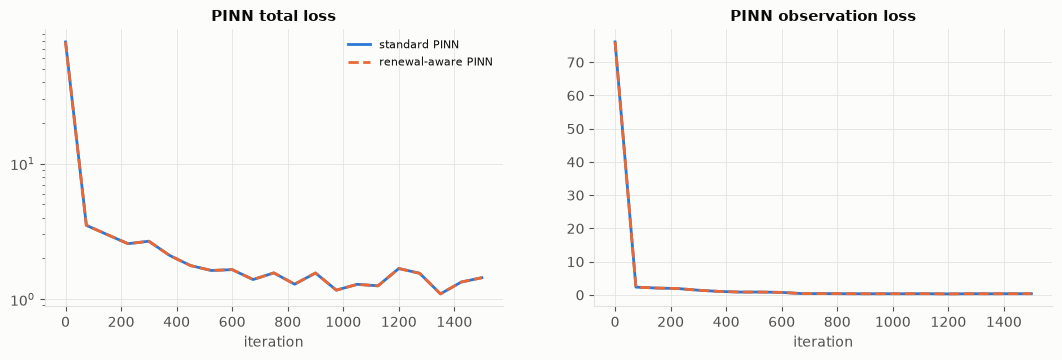

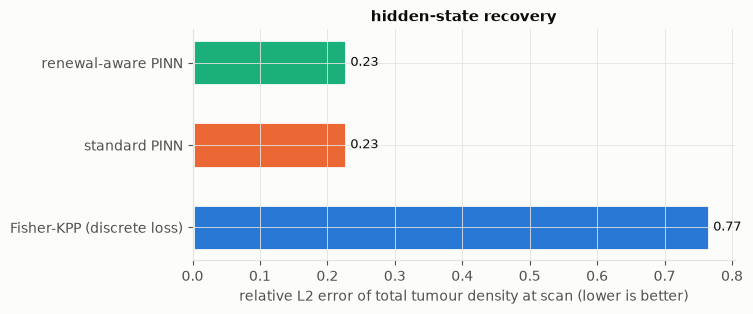

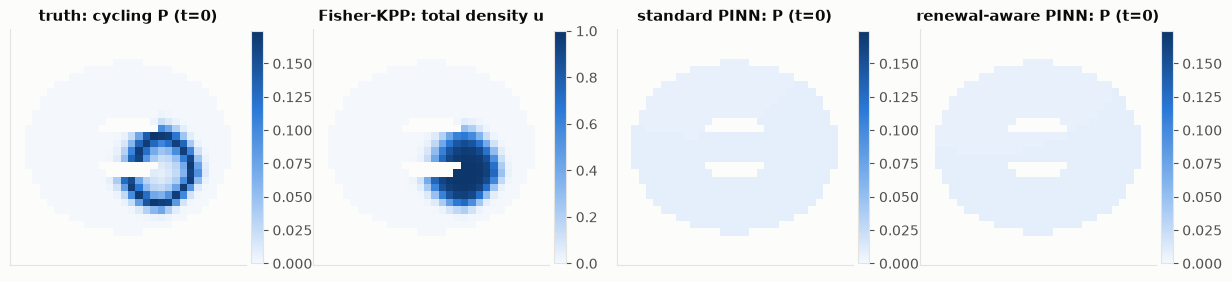

In [19]:
fig, axs = plt.subplots(1, 2, figsize=(13, 3.6))
for i, (label, (_, _, hist)) in enumerate(pinn_pred.items()):
    it = [h["it"] for h in hist]
    axs[0].plot(it, [h["loss"] for h in hist], color=SERIES[i], ls=DASHES[i], label=label)
    axs[1].plot(it, [h["obs"] for h in hist], color=SERIES[i], ls=DASHES[i], label=label)
axs[0].set_yscale("log"); axs[0].set_title("PINN total loss"); axs[1].set_title("PINN observation loss")
for a in axs: a.set_xlabel("iteration")
axs[0].legend(fontsize=8)
savefig(fig, "09_pinn_training"); plt.show()

methods = [k for k in bench if "PINN" in k or "KPP" in k]
fig, ax = plt.subplots(figsize=(7, 3))
vals = [bench[k]["total_rel_l2_t0"] for k in methods]
ax.barh(methods, vals, color=[SERIES[i] for i in range(len(methods))], height=0.55, edgecolor="#fcfcfb", lw=2)
for y, v in enumerate(vals):
    ax.text(v, y, f" {v:.2f}", va="center", fontsize=9, color=TEXT)
ax.set_xlabel("relative L2 error of total tumour density at scan (lower is better)")
ax.set_title("hidden-state recovery")
savefig(fig, "09b_method_errors"); plt.show()

fig, axs = plt.subplots(1, 4, figsize=(15, 3.4))
vmax = T0["P"].max()
show_map(axs[0], T0["P"], "truth: cycling P (t=0)", bm, vmin=0, vmax=vmax)
show_map(axs[1], u, "Fisher-KPP: total density u", bm, vmin=0, vmax=1)
for ax, label in zip(axs[2:], pinn_pred):
    show_map(ax, pinn_pred[label][0]["P"], f"{label}: P (t=0)", bm, vmin=0, vmax=vmax)
savefig(fig, "09c_method_maps"); plt.show()

## 10. Robustness to segmentation uncertainty

The same truth is fitted from synthetic segmentations with increasing boundary noise.

,relL2_P,relL2_q,relL2_r,z_D_white,z_beta_max,z_mu_p,z_T_seed
boundary_noise,,,,,,,
0.0,0.062,0.082,0.050,-0.951,-0.387,-4.304e-01,0.718
0.7,0.052,0.091,0.037,-0.584,-0.540,3.087e-04,0.828
1.4,0.086,0.137,0.056,-0.046,-0.677,2.407e-01,0.860


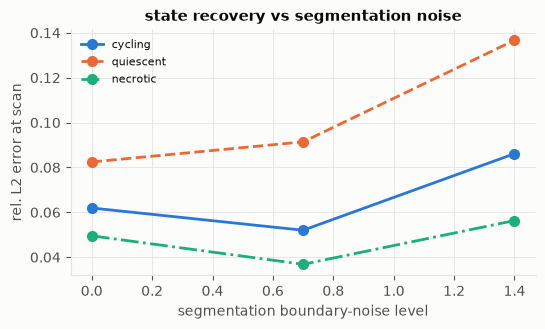

In [20]:
rob = segmentation_robustness(domain, TRUTH, center, levels=S["robustness_levels"], seed=SEED, dt=S["dt"],
                              fit_kwargs=dict(n_adam=S["n_adam"] // 2, n_lbfgs=0), fit_names=FIT_NAMES)
rob_df = pd.DataFrame([{"boundary_noise": r["boundary_noise"], **{f"relL2_{k}": v for k, v in r["state_rel_l2"].items()},
                        **{f"z_{k}": v for k, v in r["z_scores"].items()}} for r in rob]).set_index("boundary_noise")
display(rob_df)
fig, ax = plt.subplots(figsize=(6, 3.2))
for i, (k, lab) in enumerate((("P", "cycling"), ("q", "quiescent"), ("r", "necrotic"))):
    ax.plot(rob_df.index, rob_df[f"relL2_{k}"], "o", ls=DASHES[i], color=SERIES[i], label=lab, ms=7)
ax.set_xlabel("segmentation boundary-noise level"); ax.set_ylabel("rel. L2 error at scan")
ax.set_title("state recovery vs segmentation noise"); ax.legend(fontsize=8)
savefig(fig, "10_robustness"); plt.show()

## 11. Real-data anchoring (UPENN-GBM)

Runs only when `USE_REAL_DATA = True`. The case's expert soft labels are fitted directly. The
anatomy and observations are patient-specific; drug and immune kinetics remain population priors.

In [21]:
if USE_REAL_DATA and real_domain is not None:
    from glioma_scenarios.pipeline import AnalysisConfig, analyze
    real = analyze(real_domain, f"Treatment scenarios for {CASE_ID}",
                   cfg=AnalysisConfig(dt=S["dt"], n_adam=S["n_adam"], n_scenario_samples=S["n_samples"],
                                      scenario=ScenarioConfig(horizon_days=S["horizon"])),
                   out_dir=OUT / CASE_ID, verbose=False)
    display(pd.DataFrame(real["posterior"]).set_index("name"))
    for i, c in enumerate(real["equivalence"]["classes"], 1):
        print(f"{i}. " + ", ".join(c))
else:
    print("USE_REAL_DATA is False - skipped. Point UPENN_ROOT at the TCIA NIfTI release to enable.")

USE_REAL_DATA is False - skipped. Point UPENN_ROOT at the TCIA NIfTI release to enable.


## 12. Report

The synthetic analysis is written out as Markdown and JSON, including where each quantity comes
from and which claims the analysis does not make.

In [22]:
prov = {"anatomy": domain.meta.get("source", "phantom"),
        "observations": "synthetic soft labels from known truth (boundary noise 0.7)",
        "fitted parameters": ", ".join(FIT_NAMES) + " (log-normal priors, Laplace uncertainty)",
        "drug & immune parameters": "sampled from population priors (scenario inputs)"}
report = markdown_report("Notebook: synthetic ground-truth analysis", prov,
                         classify_parameters(F, FIT_NAMES), summ, eq, seed_rows, seeding_statement(seed_rows))
(OUT / "report.md").write_text(report)
save_json(dict(fit=fit_table.reset_index().to_dict("records"), identifiability=ident, outcomes=summ,
               equivalence=eq, seeding=seed_rows, benchmark=bench, robustness=rob,
               oracle_coverage=cover, settings=S), OUT / "notebook_results.json")
print("written:", sorted(p.name for p in OUT.iterdir()))
from IPython.display import Markdown
Markdown(report)

written: ['01_anatomy.png', '02_truth_and_observation.png', '02b_age_distribution.png', '03_oracle_scenarios.png', '04_map_convergence.png', '04b_state_recovery.png', '05_posterior_correlation.png', '05b_profile_likelihood.png', '06_laplace_vs_hmc.png', '07_posterior_vs_oracle.png', '07b_verdicts.png', '08_seeding.png', '09_pinn_training.png', '09b_method_errors.png', '09c_method_maps.png', '10_robustness.png', 'notebook_results.json', 'report.md']


# Notebook: synthetic ground-truth analysis

_Research tool for uncertainty-aware treatment-scenario analysis. Not a clinical decision system; outputs are not individual prescriptions._

## What comes from where

- **anatomy**: phantom
- **observations**: synthetic soft labels from known truth (boundary noise 0.7)
- **fitted parameters**: D_white, beta_max, mu_p, T_seed (log-normal priors, Laplace uncertainty)
- **drug & immune parameters**: sampled from population priors (scenario inputs)

## Identifiability

| parameter | verdict | posterior/prior variance reduction |
|---|---|---|
| D_white | identifiable | 0.93 |
| beta_max | identifiable only in combination | 0.32 |
| mu_p | identifiable | 0.79 |
| T_seed | identifiable | 0.92 |
| gray_white_ratio | not identifiable from a single pre-treatment MRI (population prior) | 0.00 |
| a_min | not identifiable from a single pre-treatment MRI (population prior) | 0.00 |
| gamma_qp | not identifiable from a single pre-treatment MRI (population prior) | 0.00 |
| sigma_half | not identifiable from a single pre-treatment MRI (population prior) | 0.00 |
| lambda_r | not identifiable from a single pre-treatment MRI (population prior) | 0.00 |
| D_E | not identifiable from a single pre-treatment MRI (population prior) | 0.00 |
| a_E | not identifiable from a single pre-treatment MRI (population prior) | 0.00 |
| k_E | not identifiable from a single pre-treatment MRI (population prior) | 0.00 |
| delta_E | not identifiable from a single pre-treatment MRI (population prior) | 0.00 |
| eps_E | not identifiable from a single pre-treatment MRI (population prior) | 0.00 |
| kappa_E | not identifiable from a single pre-treatment MRI (population prior) | 0.00 |
| w_E | not identifiable from a single pre-treatment MRI (population prior) | 0.00 |
| c_per_mg | not identifiable from a single pre-treatment MRI (population prior) | 0.00 |
| k_el | not identifiable from a single pre-treatment MRI (population prior) | 0.00 |
| k_in | not identifiable from a single pre-treatment MRI (population prior) | 0.00 |
| k_out | not identifiable from a single pre-treatment MRI (population prior) | 0.00 |
| D_C | not identifiable from a single pre-treatment MRI (population prior) | 0.00 |
| kappa_max | not identifiable from a single pre-treatment MRI (population prior) | 0.00 |
| EC50 | not identifiable from a single pre-treatment MRI (population prior) | 0.00 |
| hill | not identifiable from a single pre-treatment MRI (population prior) | 0.00 |
| phase_center | not identifiable from a single pre-treatment MRI (population prior) | 0.00 |
| phase_width | not identifiable from a single pre-treatment MRI (population prior) | 0.00 |
| phase_base | not identifiable from a single pre-treatment MRI (population prior) | 0.00 |
| q_drug_sens | not identifiable from a single pre-treatment MRI (population prior) | 0.00 |
| gamma_C | not identifiable from a single pre-treatment MRI (population prior) | 0.00 |
| seed_amp | not identifiable from a single pre-treatment MRI (population prior) | 0.00 |
| seed_radius | not identifiable from a single pre-treatment MRI (population prior) | 0.00 |

Identifiable combinations (log-linear): `D_white^+0.46 * beta_max^+0.38 * mu_p^-0.27 * T_seed^+1.00`; `D_white^+1.00 * beta_max^-0.35 * T_seed^-0.31`; `beta_max^-0.36 * mu_p^+1.00 * T_seed^+0.44`

## Scenario outcomes (median [5%, 95%])

| schedule | total dose (mg) | mean viable burden | core volume at horizon (mL) | time to progression (d) |
|---|---|---|---|---|
| no drug | 0 | 0.45 [0.287, 0.534] | 2.84 [2.57, 3.48] | 9 [7, 10.2] |
| low exposure 5d | 675 | 0.354 [0.202, 0.477] | 2.72 [1.98, 3.26] | 14.5 [7, 28.5] |
| high exposure 5d | 1350 | 0.295 [0.136, 0.468] | 2.59 [1.6, 3.18] | 20 [7.75, 35.2] |
| 7-day course | 945 | 0.324 [0.168, 0.472] | 2.68 [1.77, 3.24] | 16 [7, 33] |
| 14-day course | 1890 | 0.251 [0.0738, 0.468] | 2.5 [1.09, 3.16] | 19.5 [7, 42] |
| metronomic 28d (same total as 5d pulse) | 1350 | 0.283 [0.0897, 0.477] | 2.54 [1.17, 3.24] | 11.5 [7, 42] |

## Treatment-equivalence classes (metric: auc_viable)

1. 'no drug'
2. 'low exposure 5d'
3. 'high exposure 5d'
4. '7-day course'
5. '14-day course'
6. 'metronomic 28d (same total as 5d pulse)'

### Pairwise statements

- [not supported] No reliable comparison of 'no drug' vs 'low exposure 5d' on auc_viable: the relevant parameters are not constrained enough (driven mainly by population drug/immune priors). The direction favours 'low exposure 5d' in >= 90% of draws, but the size of the difference is not resolved relative to the 10% margin.
- [not supported] No reliable comparison of 'no drug' vs 'high exposure 5d' on auc_viable: the relevant parameters are not constrained enough (driven mainly by population drug/immune priors). The direction favours 'high exposure 5d' in >= 90% of draws, but the size of the difference is not resolved relative to the 10% margin.
- [not supported] No reliable comparison of 'no drug' vs '7-day course' on auc_viable: the relevant parameters are not constrained enough (driven mainly by population drug/immune priors). The direction favours '7-day course' in >= 90% of draws, but the size of the difference is not resolved relative to the 10% margin.
- [not supported] No reliable comparison of 'no drug' vs '14-day course' on auc_viable: the relevant parameters are not constrained enough (driven mainly by population drug/immune priors). The direction favours '14-day course' in >= 90% of draws, but the size of the difference is not resolved relative to the 10% margin.
- [not supported] No reliable comparison of 'no drug' vs 'metronomic 28d (same total as 5d pulse)' on auc_viable: the relevant parameters are not constrained enough (driven mainly by population drug/immune priors). The direction favours 'metronomic 28d (same total as 5d pulse)' in >= 90% of draws, but the size of the difference is not resolved relative to the 10% margin.
- [not supported] No reliable comparison of 'low exposure 5d' vs 'high exposure 5d' on auc_viable: the relevant parameters are not constrained enough (driven mainly by population drug/immune priors). The direction favours 'high exposure 5d' in >= 90% of draws, but the size of the difference is not resolved relative to the 10% margin.
- [not supported] No reliable comparison of 'low exposure 5d' vs '7-day course' on auc_viable: the relevant parameters are not constrained enough (driven mainly by population drug/immune priors). The direction favours '7-day course' in >= 90% of draws, but the size of the difference is not resolved relative to the 10% margin.
- [not supported] No reliable comparison of 'low exposure 5d' vs '14-day course' on auc_viable: the relevant parameters are not constrained enough. The direction favours '14-day course' in >= 90% of draws, but the size of the difference is not resolved relative to the 10% margin.
- [not supported] No reliable comparison of 'low exposure 5d' vs 'metronomic 28d (same total as 5d pulse)' on auc_viable: the relevant parameters are not constrained enough.
- [not supported] No reliable comparison of 'high exposure 5d' vs '7-day course' on auc_viable: the relevant parameters are not constrained enough (driven mainly by population drug/immune priors).
- [not supported] No reliable comparison of 'high exposure 5d' vs '14-day course' on auc_viable: the relevant parameters are not constrained enough.
- [not supported] No reliable comparison of 'high exposure 5d' vs 'metronomic 28d (same total as 5d pulse)' on auc_viable: the relevant parameters are not constrained enough.
- [not supported] No reliable comparison of '7-day course' vs '14-day course' on auc_viable: the relevant parameters are not constrained enough. The direction favours '14-day course' in >= 90% of draws, but the size of the difference is not resolved relative to the 10% margin.
- [not supported] No reliable comparison of '7-day course' vs 'metronomic 28d (same total as 5d pulse)' on auc_viable: the relevant parameters are not constrained enough.
- [not supported] No reliable comparison of '14-day course' vs 'metronomic 28d (same total as 5d pulse)' on auc_viable: the relevant parameters are not constrained enough (driven mainly by population drug/immune priors). The direction favours '14-day course' in >= 90% of draws, but the size of the difference is not resolved relative to the 10% margin.

## Effective time since seeding (model-dependent)

| assumption | median | 90% interval |
|---|---|---|
| baseline | 56 d | 46-70 d |
| small seed (x0.3) | 60 d | 47-74 d |
| large seed (x3) | 54 d | 43-68 d |
| sensitive detection | 56 d | 46-70 d |
| insensitive detection | 56 d | 45-71 d |

Effective time since seeding (model-dependent, not an observed tumour age): 90% intervals across the tested assumptions span 43-74 days.

## Claims this analysis does NOT make

- It does not claim that a single MRI directly measures immune activity.
- It does not claim that a single MRI directly measures drug concentration in brain tissue.
- It does not claim that drug sensitivity has been individually calibrated for this patient.
- It does not claim that the exact biological age of the tumour is known.
- It does not claim that the best clinical drug schedule for this individual has been determined.
- It does not claim that MRI segmentations are direct measurements of cycling, quiescent and necrotic cells.
